# 🫒 Détection des Maladies de l'Olivier — Deep Learning

---

| Informations | Détails |
|---|---|
| **Encadrant** | M. Abdallah Khemais |
| **Notebook** | 4 / 6 — Transfer Learning (ResNet50 vs VGG16) |
| **Objectif** | Fine-tuning de modèles pré-entraînés sur ImageNet |

---

## 🎯 Objectif de ce Notebook

1. ✅ Charger **ResNet50** pré-entraîné sur ImageNet
2. ✅ Charger **VGG16** pré-entraîné sur ImageNet
3. ✅ Fine-tuning en **2 phases** (Feature extraction → Dégel)
4. ✅ Comparer les performances avec le CNN Baseline
5. ✅ Analyser le problème de **gradient vanishing**

---

## 🔑 Concepts clés

| Concept | Explication |
|---|---|
| **Transfer Learning** | Réutiliser les poids appris sur ImageNet (1.2M images) |
| **Feature Extraction** | Geler la base → entraîner seulement la tête |
| **Fine-tuning** | Dégeler les dernières couches → affiner sur notre dataset |
| **Gradient Vanishing** | Dans les réseaux profonds, le gradient devient très petit → ResNet résout ce problème avec les skip connections |
| **Skip Connections** | Connexions résiduelles de ResNet : `output = F(x) + x` |

---
## 📦 Cellule 1 — Import & Configuration

> **Explication :** Import de toutes les librairies et reconstruction du pipeline depuis NB2.

In [1]:
# ============================================================
# Cellule 1 — Import & Configuration
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os, json, warnings

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50, VGG16
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)
plt.rcParams['figure.dpi'] = 120
plt.style.use('seaborn-v0_8-whitegrid')

# Chargement config
with open('/kaggle/input/notebooks/ahmedboudriga/nb2-preprocessing-augmentation/config.json', 'r') as f:
    config = json.load(f)

IMG_SIZE    = config['img_size']
BATCH_SIZE  = config['batch_size']
NUM_CLASSES = config['num_classes']
AUTOTUNE    = tf.data.AUTOTUNE
idx_to_class = {int(k): v for k, v in config['idx_to_class'].items()}
CLASS_NAMES  = [idx_to_class[i] for i in range(NUM_CLASSES)]

# Chargement splits
X_train = np.load('/kaggle/input/notebooks/ahmedboudriga/nb2-preprocessing-augmentation/X_train.npy', allow_pickle=True)
X_val   = np.load('/kaggle/input/notebooks/ahmedboudriga/nb2-preprocessing-augmentation/X_val.npy',   allow_pickle=True)
X_test  = np.load('/kaggle/input/notebooks/ahmedboudriga/nb2-preprocessing-augmentation/X_test.npy',  allow_pickle=True)
y_train = np.load('/kaggle/input/notebooks/ahmedboudriga/nb2-preprocessing-augmentation/y_train.npy')
y_val   = np.load('/kaggle/input/notebooks/ahmedboudriga/nb2-preprocessing-augmentation/y_val.npy')
y_test  = np.load('/kaggle/input/notebooks/ahmedboudriga/nb2-preprocessing-augmentation/y_test.npy')

# Reconstruction pipeline
data_aug = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1),
    layers.RandomTranslation(0.1, 0.1),
], name='data_augmentation')

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def augment_image(img, label):
    return data_aug(img, training=True), label

def build_dataset(paths, labels, augment=False, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((paths.tolist(), labels.tolist()))
    if shuffle:
        ds = ds.shuffle(len(paths), seed=42)
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    if augment:
        ds = ds.map(augment_image, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = build_dataset(X_train, y_train, augment=True,  shuffle=True)
val_ds   = build_dataset(X_val,   y_val,   augment=False, shuffle=False)
test_ds  = build_dataset(X_test,  y_test,  augment=False, shuffle=False)

print('Configuration chargée et pipeline reconstruit !')
print(f'  Classes : {CLASS_NAMES}')

2026-05-13 21:51:11.096714: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778709071.290405      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778709071.350604      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778709071.817805      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778709071.817850      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778709071.817853      23 computation_placer.cc:177] computation placer alr

Configuration chargée et pipeline reconstruit !
  Classes : ['Kus_Gozu_Mantari', 'Pas_Akari', 'Saglikli']


---
## 🔵 Cellule 2 — Architecture ResNet50

> **Explication :** ResNet50 (Residual Network) a été introduit par He et al. en 2015.
> Il résout le problème du **gradient vanishing** grâce aux **skip connections** :
> ```
> output = F(x) + x   ← le gradient peut toujours circuler via x
> ```
> - 50 couches de profondeur
> - Pré-entraîné sur **ImageNet** (1.2 million d'images, 1000 classes)
> - On remplace la tête (1000 classes) par notre tête (3 classes)
>
> **Stratégie de fine-tuning en 2 phases :**
> - **Phase 1** : Geler toute la base ResNet → entraîner seulement la nouvelle tête (~5 epochs)
> - **Phase 2** : Dégeler les 30 dernières couches → affiner avec un lr très faible

In [2]:
# ============================================================
# Cellule 2 — Construction du modèle ResNet50
# Transfer Learning : base ImageNet + nouvelle tête 3 classes
# ============================================================

def build_resnet50(input_shape=(224, 224, 3), num_classes=3):
    """
    ResNet50 pré-entraîné sur ImageNet avec nouvelle tête de classification.
    include_top=False : on enlève la tête originale (1000 classes ImageNet)
    """
    # Chargement de la base ResNet50 SANS la tête de classification
    base_model = ResNet50(
        weights='imagenet',      # Poids pré-entraînés sur ImageNet
        include_top=False,       # On enlève la couche Dense finale
        input_shape=input_shape  # Notre taille d'entrée
    )

    # Phase 1 : Geler toute la base (Feature Extraction)
    # Les poids ImageNet sont conservés intacts
    base_model.trainable = False

    # Construction du modèle complet
    inputs = layers.Input(shape=input_shape)
    x = base_model(inputs, training=False)  # training=False = BN en mode inférence

    # Nouvelle tête de classification pour nos 3 maladies
    x = layers.GlobalAveragePooling2D(name='gap')(x)  # (7,7,2048) → (2048,)
    x = layers.Dense(512, name='dense1')(x)
    x = layers.BatchNormalization(name='bn1')(x)
    x = layers.Activation('relu', name='relu1')(x)
    x = layers.Dropout(0.4, name='drop1')(x)
    x = layers.Dense(128, name='dense2')(x)
    x = layers.BatchNormalization(name='bn2')(x)
    x = layers.Activation('relu', name='relu2')(x)
    x = layers.Dropout(0.3, name='drop2')(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='output')(x)

    model = models.Model(inputs=inputs, outputs=outputs, name='ResNet50_Transfer')
    return model, base_model

resnet_model, resnet_base = build_resnet50(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    num_classes=NUM_CLASSES
)

print('Architecture ResNet50 construite !')
print(f'  Couches totales ResNet50   : {len(resnet_base.layers)}')
print(f'  Paramètres base (gelés)    : {resnet_base.count_params():,}')
print(f'  Paramètres tête (à entraîner) : {resnet_model.count_params() - resnet_base.count_params():,}')
print(f'  Paramètres totaux          : {resnet_model.count_params():,}')

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Architecture ResNet50 construite !
  Couches totales ResNet50   : 175
  Paramètres base (gelés)    : 23,587,712
  Paramètres tête (à entraîner) : 1,117,699
  Paramètres totaux          : 24,705,411


---
## 🔵 Cellule 3 — Entraînement ResNet50 Phase 1 (Feature Extraction)

> **Explication :** Dans la Phase 1, la base ResNet50 est complètement **gelée**.
> Seule la nouvelle tête de classification est entraînée.
> Cela permet d'initialiser correctement la tête avant le fine-tuning.

In [3]:
# ============================================================
# Cellule 3 — Phase 1 : Feature Extraction ResNet50
# Base gelée, entraînement de la tête uniquement
# ============================================================

# Compilation Phase 1 : lr élevé car seulement la tête
resnet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

callbacks_phase1 = [
    EarlyStopping(monitor='val_loss', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-6, verbose=1)
]

print('Phase 1 — Feature Extraction (base gelée)...')
print(f'  Couches entraînables : {len([l for l in resnet_model.layers if l.trainable])}')

history_resnet_p1 = resnet_model.fit(
    train_ds, epochs=10,
    validation_data=val_ds,
    callbacks=callbacks_phase1,
    verbose=1
)

print(f'\nPhase 1 terminée !')
print(f'  Best val_accuracy : {max(history_resnet_p1.history["val_accuracy"]):.4f}')

Phase 1 — Feature Extraction (base gelée)...
  Couches entraînables : 11
Epoch 1/10


I0000 00:00:1778709110.305280      69 service.cc:152] XLA service 0x7b91fc0044f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778709110.305346      69 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778709110.305353      69 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778709112.818325      69 cuda_dnn.cc:529] Loaded cuDNN version 91002


 1/22 ━━━━━━━━━━━━━━━━━━━━ 6:05 17s/step - accuracy: 0.2188 - loss: 1.7529

I0000 00:00:1778709119.365017      69 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


22/22 ━━━━━━━━━━━━━━━━━━━━ 38s 971ms/step - accuracy: 0.3754 - loss: 1.3773 - val_accuracy: 0.4694 - val_loss: 1.0448 - learning_rate: 0.0010
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 294ms/step - accuracy: 0.5349 - loss: 1.0516 - val_accuracy: 0.2789 - val_loss: 1.1506 - learning_rate: 0.0010
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 290ms/step - accuracy: 0.5570 - loss: 1.0391 - val_accuracy: 0.3265 - val_loss: 1.0858 - learning_rate: 0.0010
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - accuracy: 0.5729 - loss: 0.9517
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 290ms/step - accuracy: 0.5733 - loss: 0.9521 - val_accuracy: 0.2925 - val_loss: 1.1094 - learning_rate: 0.0010
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 296ms/step - accuracy: 0.5560 - loss: 1.0733 - val_accuracy: 0.4694 - val_loss: 1.0407 - learning_rate: 5.0000e-04
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 285ms/step - accuracy: 0.5852 - loss: 0.9426 - val_acc

---
## 🔵 Cellule 4 — Entraînement ResNet50 Phase 2 (Fine-tuning)

> **Explication :** Dans la Phase 2, on **dégèle les 30 dernières couches** de ResNet50.
> On utilise un learning rate **très faible** (1e-5) pour ne pas détruire les poids pré-entraînés.
> Le modèle peut maintenant adapter ses features aux feuilles d'olivier.

In [4]:
# ============================================================
# Cellule 4 — Phase 2 : Fine-tuning ResNet50
# Dégel des 30 dernières couches + lr très faible
# ============================================================

# Dégeler les 30 dernières couches de la base
resnet_base.trainable = True
for layer in resnet_base.layers[:-30]:
    layer.trainable = False  # Geler tout sauf les 30 dernières couches

trainable_count = sum(1 for l in resnet_model.layers if l.trainable)
print(f'Phase 2 — Fine-tuning (30 dernières couches dégelées)')
print(f'  Couches entraînables : {trainable_count}')

# Recompilation avec lr très faible pour ne pas écraser les poids
resnet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),  # 100x plus faible
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

RESNET_PATH = '/kaggle/working/resnet50_best.h5'
callbacks_phase2 = [
    EarlyStopping(monitor='val_loss', patience=7,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint(RESNET_PATH, monitor='val_accuracy',
                    save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=4, min_lr=1e-8, verbose=1)
]

history_resnet_p2 = resnet_model.fit(
    train_ds, epochs=20,
    validation_data=val_ds,
    callbacks=callbacks_phase2,
    verbose=1
)

# Évaluation finale
resnet_loss, resnet_acc = resnet_model.evaluate(test_ds, verbose=0)
print(f'\nRésultats ResNet50 sur Test Set :')
print(f'  Test Accuracy : {resnet_acc:.4f} ({resnet_acc*100:.2f}%)')
print(f'  Test Loss     : {resnet_loss:.4f}')

Phase 2 — Fine-tuning (30 dernières couches dégelées)
  Couches entraînables : 12
Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 640ms/step - accuracy: 0.5041 - loss: 1.1347
Epoch 1: val_accuracy improved from -inf to 0.54422, saving model to /kaggle/working/resnet50_best.h5


22/22 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.5045 - loss: 1.1339 - val_accuracy: 0.5442 - val_loss: 1.0263 - learning_rate: 1.0000e-05
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - accuracy: 0.5639 - loss: 1.0286
Epoch 2: val_accuracy did not improve from 0.54422
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 324ms/step - accuracy: 0.5634 - loss: 1.0303 - val_accuracy: 0.5374 - val_loss: 1.0114 - learning_rate: 1.0000e-05
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - accuracy: 0.6111 - loss: 0.9554
Epoch 3: val_accuracy did not improve from 0.54422
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 317ms/step - accuracy: 0.6100 - loss: 0.9566 - val_accuracy: 0.4898 - val_loss: 1.0277 - learning_rate: 1.0000e-05
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - accuracy: 0.5789 - loss: 0.9713
Epoch 4: val_accuracy did not improve from 0.54422
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 322ms/step - accuracy: 0.5791 - loss: 0.9698 - val_accuracy: 0.4694 - val_loss: 1.1263 - learning_rate: 1.0000e-05
Epoch 5/20


---
## 🟡 Cellule 5 — Architecture et Entraînement VGG16

> **Explication :** VGG16 (Visual Geometry Group, 2014) est une architecture plus ancienne mais efficace.
> - 16 couches de profondeur, architecture linéaire simple
> - Plus lourd que ResNet (138M paramètres) mais bonne baseline
> - Pas de skip connections → peut souffrir du gradient vanishing sur les couches profondes
> - On applique la même stratégie de fine-tuning en 2 phases

In [5]:
# ============================================================
# Cellule 5 — VGG16 : Construction + Entraînement complet
# Fine-tuning en 2 phases (même stratégie que ResNet50)
# ============================================================

# Construction VGG16
vgg_base = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
vgg_base.trainable = False  # Gel initial

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = vgg_base(inputs, training=False)
x = layers.GlobalAveragePooling2D(name='gap')(x)
x = layers.Dense(512, activation='relu', name='dense1')(x)
x = layers.BatchNormalization(name='bn1')(x)
x = layers.Dropout(0.4, name='drop1')(x)
x = layers.Dense(128, activation='relu', name='dense2')(x)
x = layers.Dropout(0.3, name='drop2')(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax', name='output')(x)
vgg_model = models.Model(inputs=inputs, outputs=outputs, name='VGG16_Transfer')

print(f'VGG16 construit ! Paramètres totaux : {vgg_model.count_params():,}')

# ── Phase 1 : Feature Extraction ────────────────────────
vgg_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)
print('\nPhase 1 VGG16 — Feature Extraction...')
history_vgg_p1 = vgg_model.fit(
    train_ds, epochs=10, validation_data=val_ds,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5,
                             restore_best_weights=True, verbose=0)],
    verbose=1
)

# ── Phase 2 : Fine-tuning ────────────────────────────────
vgg_base.trainable = True
for layer in vgg_base.layers[:-6]:  # Dégeler les 6 dernières couches
    layer.trainable = False

VGG_PATH = '/kaggle/working/vgg16_best.h5'
vgg_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)
print('\nPhase 2 VGG16 — Fine-tuning...')
history_vgg_p2 = vgg_model.fit(
    train_ds, epochs=20, validation_data=val_ds,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=7,
                      restore_best_weights=True, verbose=1),
        ModelCheckpoint(VGG_PATH, monitor='val_accuracy',
                        save_best_only=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=4, min_lr=1e-8, verbose=0)
    ],
    verbose=1
)

vgg_loss, vgg_acc = vgg_model.evaluate(test_ds, verbose=0)
print(f'\nRésultats VGG16 sur Test Set :')
print(f'  Test Accuracy : {vgg_acc:.4f} ({vgg_acc*100:.2f}%)')
print(f'  Test Loss     : {vgg_loss:.4f}')

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
VGG16 construit ! Paramètres totaux : 15,045,443

Phase 1 VGG16 — Feature Extraction...
Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - accuracy: 0.5017 - loss: 1.1267 - val_accuracy: 0.4694 - val_loss: 1.2199
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 422ms/step - accuracy: 0.7275 - loss: 0.7020 - val_accuracy: 0.4694 - val_loss: 1.1842
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 425ms/step - accuracy: 0.7613 - loss: 0.6255 - val_accuracy: 0.4694 - val_loss: 1.2046
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 426ms/step - accuracy: 0.7591 - loss: 0.5877 - val_accuracy: 0.4762 - val_loss: 0.9795
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 435ms/step - accuracy: 0.7873 - loss: 0.5335 - val_accuracy: 0.4694 - val_loss: 0.9556
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 435ms/step - accuracy: 0.7816 - loss: 0.5075 - val_accuracy: 0.4762 - val_loss: 0.9838
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 437ms/step - accuracy: 0.8302 - loss: 0.4277 - val_

22/22 ━━━━━━━━━━━━━━━━━━━━ 32s 898ms/step - accuracy: 0.8362 - loss: 0.3838 - val_accuracy: 0.7687 - val_loss: 0.6792 - learning_rate: 1.0000e-05
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - accuracy: 0.8504 - loss: 0.3645
Epoch 2: val_accuracy improved from 0.76871 to 0.78231, saving model to /kaggle/working/vgg16_best.h5


22/22 ━━━━━━━━━━━━━━━━━━━━ 11s 500ms/step - accuracy: 0.8503 - loss: 0.3648 - val_accuracy: 0.7823 - val_loss: 0.6267 - learning_rate: 1.0000e-05
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - accuracy: 0.8638 - loss: 0.3440
Epoch 3: val_accuracy did not improve from 0.78231
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 473ms/step - accuracy: 0.8641 - loss: 0.3432 - val_accuracy: 0.7143 - val_loss: 0.6285 - learning_rate: 1.0000e-05
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step - accuracy: 0.8527 - loss: 0.3231
Epoch 4: val_accuracy did not improve from 0.78231
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 474ms/step - accuracy: 0.8526 - loss: 0.3236 - val_accuracy: 0.7483 - val_loss: 0.5950 - learning_rate: 1.0000e-05
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.8643 - loss: 0.3100
Epoch 5: val_accuracy did not improve from 0.78231
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 472ms/step - accuracy: 0.8651 - loss: 0.3090 - val_accuracy: 0.7823 - val_loss: 0.5418 - learning_rate: 1.0000e-05
Epoch

22/22 ━━━━━━━━━━━━━━━━━━━━ 11s 489ms/step - accuracy: 0.8980 - loss: 0.2513 - val_accuracy: 0.8163 - val_loss: 0.4770 - learning_rate: 1.0000e-05
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - accuracy: 0.9098 - loss: 0.2306
Epoch 8: val_accuracy did not improve from 0.81633
22/22 ━━━━━━━━━━━━━━━━━━━━ 11s 475ms/step - accuracy: 0.9099 - loss: 0.2312 - val_accuracy: 0.8163 - val_loss: 0.4505 - learning_rate: 1.0000e-05
Epoch 9/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step - accuracy: 0.9153 - loss: 0.1939
Epoch 9: val_accuracy improved from 0.81633 to 0.82993, saving model to /kaggle/working/vgg16_best.h5


22/22 ━━━━━━━━━━━━━━━━━━━━ 11s 490ms/step - accuracy: 0.9149 - loss: 0.1956 - val_accuracy: 0.8299 - val_loss: 0.4197 - learning_rate: 1.0000e-05
Epoch 10/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - accuracy: 0.9074 - loss: 0.2155
Epoch 10: val_accuracy improved from 0.82993 to 0.85034, saving model to /kaggle/working/vgg16_best.h5


22/22 ━━━━━━━━━━━━━━━━━━━━ 11s 493ms/step - accuracy: 0.9079 - loss: 0.2147 - val_accuracy: 0.8503 - val_loss: 0.4299 - learning_rate: 1.0000e-05
Epoch 11/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step - accuracy: 0.9166 - loss: 0.2126
Epoch 11: val_accuracy did not improve from 0.85034
22/22 ━━━━━━━━━━━━━━━━━━━━ 11s 478ms/step - accuracy: 0.9166 - loss: 0.2128 - val_accuracy: 0.8435 - val_loss: 0.3783 - learning_rate: 1.0000e-05
Epoch 12/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - accuracy: 0.9347 - loss: 0.1551
Epoch 12: val_accuracy improved from 0.85034 to 0.86395, saving model to /kaggle/working/vgg16_best.h5


22/22 ━━━━━━━━━━━━━━━━━━━━ 11s 492ms/step - accuracy: 0.9345 - loss: 0.1556 - val_accuracy: 0.8639 - val_loss: 0.3703 - learning_rate: 1.0000e-05
Epoch 13/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - accuracy: 0.9261 - loss: 0.1851
Epoch 13: val_accuracy did not improve from 0.86395
22/22 ━━━━━━━━━━━━━━━━━━━━ 11s 477ms/step - accuracy: 0.9261 - loss: 0.1850 - val_accuracy: 0.8163 - val_loss: 0.4345 - learning_rate: 1.0000e-05
Epoch 14/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - accuracy: 0.9250 - loss: 0.2126
Epoch 14: val_accuracy did not improve from 0.86395
22/22 ━━━━━━━━━━━━━━━━━━━━ 11s 480ms/step - accuracy: 0.9249 - loss: 0.2128 - val_accuracy: 0.8231 - val_loss: 0.4539 - learning_rate: 1.0000e-05
Epoch 15/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - accuracy: 0.9335 - loss: 0.1740
Epoch 15: val_accuracy did not improve from 0.86395
22/22 ━━━━━━━━━━━━━━━━━━━━ 11s 478ms/step - accuracy: 0.9334 - loss: 0.1742 - val_accuracy: 0.8163 - val_loss: 0.4732 - learning_rate: 1.0000e-05

22/22 ━━━━━━━━━━━━━━━━━━━━ 11s 498ms/step - accuracy: 0.9229 - loss: 0.1707 - val_accuracy: 0.8776 - val_loss: 0.3891 - learning_rate: 5.0000e-06
Epoch 19/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - accuracy: 0.9496 - loss: 0.1335
Epoch 19: val_accuracy did not improve from 0.87755
22/22 ━━━━━━━━━━━━━━━━━━━━ 11s 481ms/step - accuracy: 0.9493 - loss: 0.1342 - val_accuracy: 0.8503 - val_loss: 0.4016 - learning_rate: 5.0000e-06
Epoch 19: early stopping
Restoring model weights from the end of the best epoch: 12.

Résultats VGG16 sur Test Set :
  Test Accuracy : 0.9184 (91.84%)
  Test Loss     : 0.2228


---
## 📊 Cellule 6 — Courbes d'apprentissage & Comparaison

> **Explication :** On trace les courbes des deux modèles côte à côte pour comparer leur convergence.

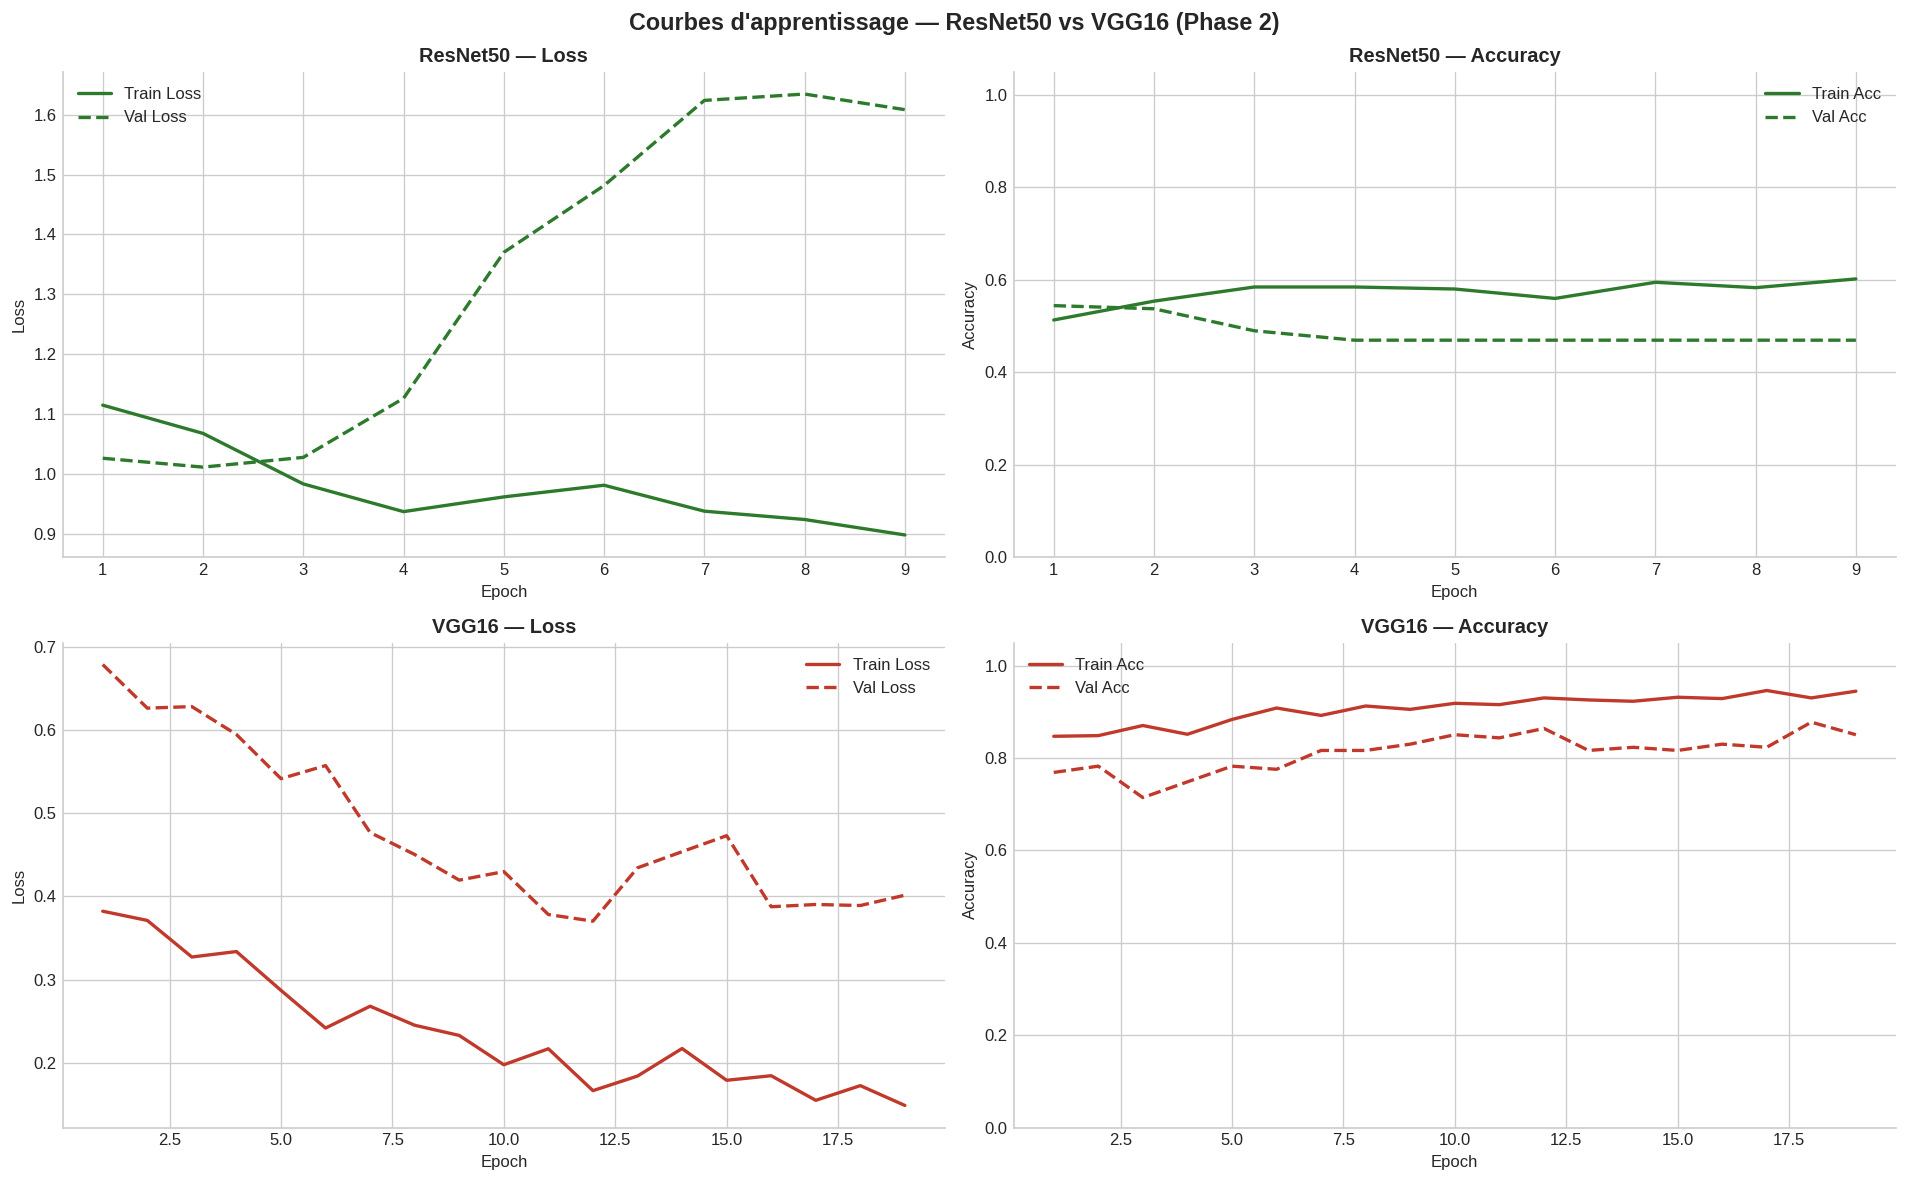

Figure sauvegardée --> /kaggle/working/10_learning_curves_resnet_vgg.png


In [6]:
# ============================================================
# Cellule 6 — Courbes d'apprentissage ResNet50 vs VGG16
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Courbes d\'apprentissage — ResNet50 vs VGG16 (Phase 2)',
             fontsize=14, fontweight='bold')

for row, (hist, name, color) in enumerate([
    (history_resnet_p2, 'ResNet50', '#2d7a2d'),
    (history_vgg_p2,   'VGG16',   '#c0392b')
]):
    h = hist.history
    ep = range(1, len(h['loss']) + 1)

    # Loss
    axes[row, 0].plot(ep, h['loss'],     label='Train Loss', color=color, lw=2)
    axes[row, 0].plot(ep, h['val_loss'], label='Val Loss',   color=color, lw=2, ls='--')
    axes[row, 0].set_title(f'{name} — Loss', fontweight='bold')
    axes[row, 0].set_xlabel('Epoch')
    axes[row, 0].set_ylabel('Loss')
    axes[row, 0].legend()
    axes[row, 0].spines[['top','right']].set_visible(False)

    # Accuracy
    axes[row, 1].plot(ep, h['accuracy'],     label='Train Acc', color=color, lw=2)
    axes[row, 1].plot(ep, h['val_accuracy'], label='Val Acc',   color=color, lw=2, ls='--')
    axes[row, 1].set_title(f'{name} — Accuracy', fontweight='bold')
    axes[row, 1].set_xlabel('Epoch')
    axes[row, 1].set_ylabel('Accuracy')
    axes[row, 1].set_ylim(0, 1.05)
    axes[row, 1].legend()
    axes[row, 1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('/kaggle/working/10_learning_curves_resnet_vgg.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée --> /kaggle/working/10_learning_curves_resnet_vgg.png')

---
## 🔲 Cellule 7 — Matrices de Confusion ResNet50 & VGG16

> **Explication :** On calcule et visualise les matrices de confusion des deux modèles
> pour identifier quelles classes sont bien ou mal classifiées.

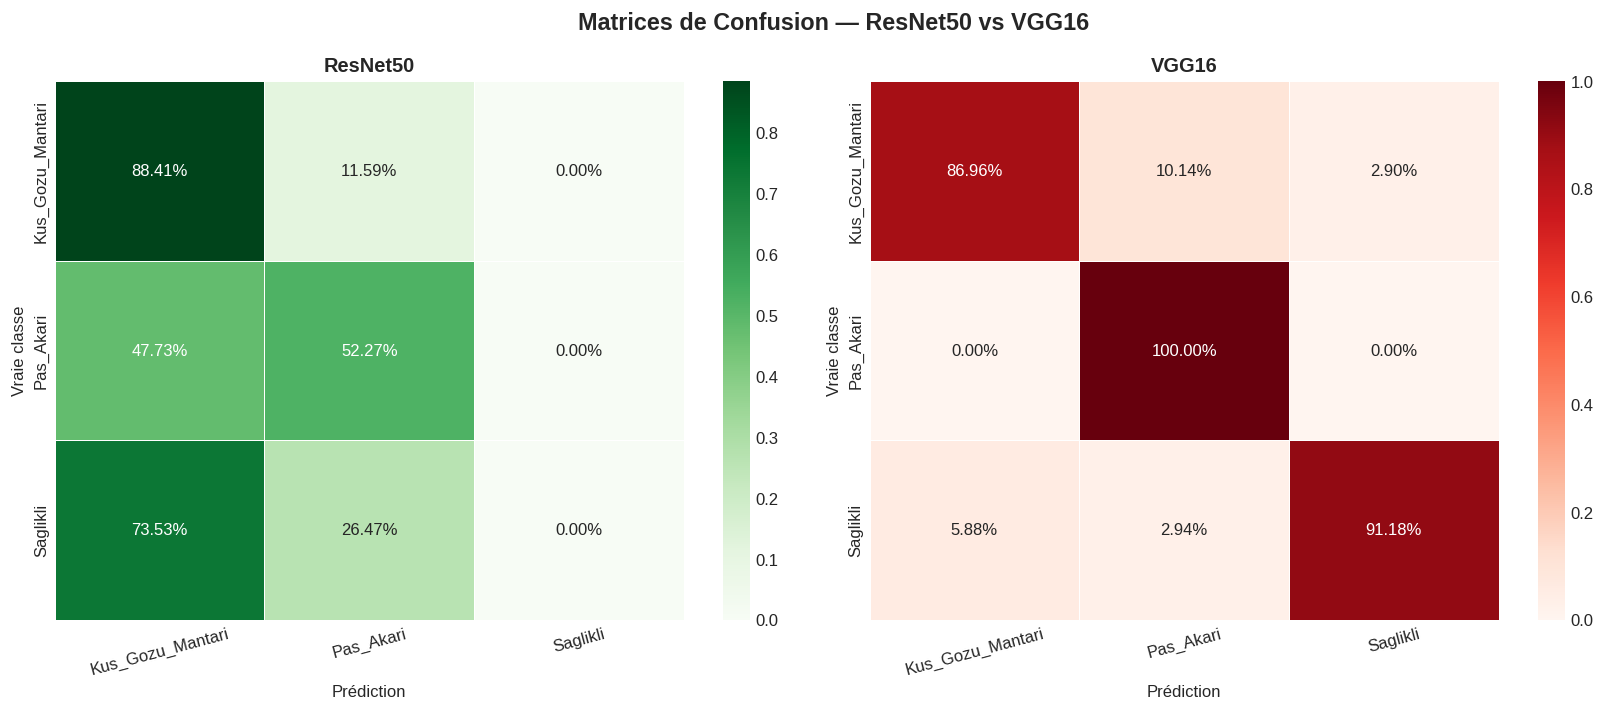

Figure sauvegardée --> /kaggle/working/11_confusion_resnet_vgg.png


In [7]:
# ============================================================
# Cellule 7 — Matrices de Confusion ResNet50 & VGG16
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Matrices de Confusion — ResNet50 vs VGG16', fontsize=14, fontweight='bold')

for ax, (model, name, cmap) in zip(axes, [
    (resnet_model, 'ResNet50', 'Greens'),
    (vgg_model,   'VGG16',   'Reds')
]):
    y_pred = np.argmax(model.predict(test_ds, verbose=0), axis=1)
    cm = confusion_matrix(y_test, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap=cmap,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, linewidths=0.5)
    ax.set_title(f'{name}', fontweight='bold')
    ax.set_xlabel('Prédiction')
    ax.set_ylabel('Vraie classe')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('/kaggle/working/11_confusion_resnet_vgg.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée --> /kaggle/working/11_confusion_resnet_vgg.png')

---
## 💾 Cellule 8 — Sauvegarde des Résultats

> **Explication :** On sauvegarde les résultats de ResNet50 et VGG16 dans `config.json`
> pour le tableau de comparaison final dans NB6.

In [8]:
# ============================================================
# Cellule 8 — Sauvegarde des Résultats
# ============================================================

config['results'] = config.get('results', {})

config['results']['ResNet50'] = {
    'test_accuracy' : round(float(resnet_acc), 4),
    'test_loss'     : round(float(resnet_loss), 4),
    'total_params'  : resnet_model.count_params(),
    'model_path'    : RESNET_PATH,
}
config['results']['VGG16'] = {
    'test_accuracy' : round(float(vgg_acc), 4),
    'test_loss'     : round(float(vgg_loss), 4),
    'total_params'  : vgg_model.count_params(),
    'model_path'    : VGG_PATH,
}

with open('/kaggle/working/config.json', 'w', encoding='utf-8') as f:
    json.dump(config, f, indent=2, ensure_ascii=False)

# Résumé comparatif
cnn_acc = config['results'].get('CNN_Baseline', {}).get('test_accuracy', 0)
print('=' * 55)
print('Comparaison des modèles (jusqu\'à présent)')
print('=' * 55)
print(f'  CNN Baseline : {cnn_acc*100:.2f}%')
print(f'  ResNet50     : {resnet_acc*100:.2f}%')
print(f'  VGG16        : {vgg_acc*100:.2f}%')
print('=' * 55)
print('\nRésultats sauvegardés dans config.json')
print('\n🚀 Prochain notebook : NB5 — EfficientNetB4 (modèle final)')

Comparaison des modèles (jusqu'à présent)
  CNN Baseline : 0.00%
  ResNet50     : 57.14%
  VGG16        : 91.84%

Résultats sauvegardés dans config.json

🚀 Prochain notebook : NB5 — EfficientNetB4 (modèle final)


---
## ✅ Récapitulatif du Notebook 4

| Cellule | Tâche | Statut |
|---------|-------|--------|
| 1 | Import & reconstruction pipeline | ✅ |
| 2 | Architecture ResNet50 (base gelée) | ✅ |
| 3 | Entraînement ResNet50 Phase 1 (Feature Extraction) | ✅ |
| 4 | Entraînement ResNet50 Phase 2 (Fine-tuning) | ✅ |
| 5 | Architecture + Entraînement VGG16 (2 phases) | ✅ |
| 6 | Courbes d'apprentissage comparées | ✅ |
| 7 | Matrices de confusion ResNet50 & VGG16 | ✅ |
| 8 | Sauvegarde résultats pour NB6 | ✅ |

---
### 🚀 Prochain Notebook — NB5 : EfficientNetB4 (Modèle Final)